# Detector results analysis

Compares **zero-shot probability-curvature** detectors (Fast-DetectGPT, DetectGPT) against a
**supervised TF-IDF + Logistic Regression** baseline on MULTITuDE and MultiSocial.

Addresses two research questions:

1. Does zero-shot probability-curvature detection outperform a supervised TF-IDF + LR lexical baseline?
2. How does detection efficacy vary across high- vs low-resource languages, and how does it relate to
   the languages in the scoring model's training data?

**Everything here uses the `test` split only**, because the TF-IDF baseline was only scored on test.

> Run order: just *Run All*. The first run parses ~1.5 GB of CSVs (several minutes) and caches the
> result; later runs load the cache in seconds.

## 0. Configuration

This is the only cell you should need to edit.

In [ ]:
from pathlib import Path

# Folder holding the unzipped result folders (the one with "Analyse MNLP" / "Analyse MNLP 2" inside)
RESULTS_DIR = Path("/Users/julian/Documents/MNLP/results-analysis")

# Project root, found by walking up from wherever the notebook was launched, so
# this works whether you start Jupyter in the repo root or in analysis/.
def _find_project_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "score.py").exists() or (p / "datasets").is_dir():
            return p
    return here

PROJECT_ROOT = _find_project_root()
CACHE_DIR = PROJECT_ROOT / "analysis" / ".cache"   # parsed-score cache (small)
OUT_DIR = PROJECT_ROOT / "analysis" / "output"     # tables written here
    
# Set True to re-parse the CSVs even if a cache exists
FORCE_RELOAD = False

# ---------------------------------------------------------------------------
# Documented pretraining-language coverage of each scoring model, restricted to
# the languages present in these datasets. Edit if you add a model.
#   gpt2-xl      : WebText, English only
#   llama3.2-1b  : Llama-3.2 model card lists 8 official languages
#                  (en, de, fr, it, pt, hi, es, th); only 4 occur here
#   qwen3-0.6b   : 119 languages claimed -> None means "treat as covering all"
MODEL_COVERAGE = {
    "gpt2-xl":     {"en"},
    "llama3.2-1b": {"en", "de", "es", "pt"},
    "qwen3-0.6b":  None,
}

# Approximate resource tiers. Coarse and debatable on purpose - change freely.
RESOURCE_TIER = {
    **{l: "high" for l in ["en","de","es","pt","nl","ru","zh","ar","pl","cs"]},
    **{l: "mid"  for l in ["el","hu","ro","bg","uk","hr","sk","sl","ca","et"]},
    **{l: "low"  for l in ["ga","gd"]},
}

# Display order and short names
VARIANT_ORDER = ["fastdetect:gpt2-xl", "fastdetect:llama3.2-1b", "fastdetect:qwen3-0.6b",
                 "detectgpt:llama3.2-1b", "detectgpt:qwen3-0.6b",
                 "tfidf:en", "tfidf:big_eu", "tfidf:less_common", "tfidf:all"]
SHORT = {"fastdetect:gpt2-xl": "FD/gpt2",  "fastdetect:llama3.2-1b": "FD/llama",
         "fastdetect:qwen3-0.6b": "FD/qwen", "detectgpt:llama3.2-1b": "DG/llama",
         "detectgpt:qwen3-0.6b": "DG/qwen", "tfidf:en": "TF/en", "tfidf:big_eu": "TF/big_eu",
         "tfidf:less_common": "TF/less_common", "tfidf:all": "TF/all"}

CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("project :", PROJECT_ROOT)
print("results :", RESULTS_DIR, "->", "FOUND" if RESULTS_DIR.exists() else "*** NOT FOUND ***")

project : /Users/julian/Documents/MNLP/Multi-lingual-NLP
results : /Users/julian/Documents/MNLP/results-analysis -> FOUND


## 1. Imports and helpers

In [2]:
import io, re, json, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)
sns.set_theme(style="whitegrid", context="notebook")

SCORE_COLS = ["dataset","row_id","label","multi_label","split","language","length","score"]
MIN_GROUP = 30   # smallest group we are willing to compute an AUROC for


def auroc(frame):
    """AUROC of score against label, or NaN when the group cannot support one."""
    if len(frame) < MIN_GROUP or frame["label"].nunique() < 2:
        return np.nan
    return roc_auc_score(frame["label"], frame["score"])


def robust_read_csv(path):
    """Read a scores.csv, tolerating a truncated file (one run was cut short).

    Returns (dataframe, n_bad_bytes_dropped).
    """
    try:
        return pd.read_csv(path, usecols=SCORE_COLS), 0
    except UnicodeDecodeError:
        raw = path.read_bytes()
        text = raw.decode("utf-8", errors="ignore")
        cut = text.rfind("\n")              # drop the partial final record
        df = pd.read_csv(io.StringIO(text[:cut]), usecols=SCORE_COLS,
                         on_bad_lines="skip", engine="python")
        return df, len(raw) - cut

## 2. Load

Three things are handled here that the raw files need:

* one `fastdetect/llama/multisocial` file is **truncated** - we recover what parses;
* one `detectgpt/llama/multisocial` run was **resumed**, leaving duplicate `row_id`s - they are
  byte-identical, so we de-duplicate;
* the TF-IDF baseline lives in a zip and each config folder holds rows for **both** datasets, so we
  keep only the in-domain rows (trained on X, evaluated on X's test split).

In [3]:
def load_baseline_all(results_dir):
    """Every TF-IDF test row, read straight out of baseline_scores.zip.

    Keeps rows for BOTH datasets (not just in-domain) so the transfer matrix in
    section 3.1 can be built from the same pass. Reading from the zip avoids
    unpacking ~1.8 GB onto disk.
    """
    zips = list(results_dir.rglob("baseline_scores.zip"))
    if not zips:
        raise FileNotFoundError(f"no baseline_scores.zip under {results_dir}")
    frames = []
    with zipfile.ZipFile(zips[0]) as z:
        members = [m for m in z.namelist() if m.endswith("scores.csv")]
        for i, member in enumerate(sorted(members), 1):
            cfg = re.sub(r"_[0-9a-f]{8}$", "",
                         member.split("/")[0].replace("baseline_weights-", "").replace("_seed42", ""))
            trained_on, lang_cfg = cfg.split("_", 1)
            print(f"  baseline {i}/{len(members)}: {cfg}", flush=True)
            with z.open(member) as fh:
                df = pd.read_csv(fh, usecols=SCORE_COLS)
            df = df[df["split"] == "test"].copy()
            df["detector"], df["model"] = "tfidf", f"tfidf-{lang_cfg}"
            df["variant"], df["trained_on"] = f"tfidf:{lang_cfg}", trained_on
            frames.append(df)
    return pd.concat(frames, ignore_index=True)


MODEL_ALIASES = {
    "gpt2-xl": "gpt2-xl",
    "Qwen-Qwen3-0.6B": "qwen3-0.6b",
    "meta-llama-Llama-3.2-1B-Instruct": "llama3.2-1b",
}


def load_neural(results_dir):
    """All fastdetect / detectgpt test rows, best copy per (detector, model, dataset)."""
    best, notes = {}, []
    for path in sorted(results_dir.rglob("scores.csv")):
        folder = path.parent.name
        if folder.startswith("fastdetect"):
            detector = "fastdetect"
        elif folder.startswith("detectgpt"):
            detector = "detectgpt"
        else:
            continue
        raw_name = re.search(r"score-([^_]+)_", folder).group(1)
        model = MODEL_ALIASES.get(raw_name, raw_name)
        df, dropped = robust_read_csv(path)
        if dropped:
            notes.append(f"{detector}/{model}: TRUNCATED file, dropped {dropped} trailing bytes")
        df = df[df["split"] == "test"]
        if df.empty:
            continue
        key = (detector, model, df["dataset"].iloc[0])
        # the same run can appear in more than one unzipped folder; keep the fullest copy
        if key not in best or len(df) > len(best[key]):
            best[key] = df
    frames = []
    for (detector, model, _), df in best.items():
        df = df.copy()
        df["detector"], df["model"] = detector, model
        df["variant"] = f"{detector}:{model}"
        frames.append(df)
    return frames, notes


scores_cache = CACHE_DIR / "test_scores.pkl"
baseline_cache = CACHE_DIR / "baseline_all.pkl"

if scores_cache.exists() and baseline_cache.exists() and not FORCE_RELOAD:
    scores = pd.read_pickle(scores_cache)
    baseline_all = pd.read_pickle(baseline_cache)
    load_notes = ["loaded from cache - set FORCE_RELOAD=True to re-parse"]
    print(f"cache hit: {len(scores):,} rows")
else:
    print("parsing result CSVs (a few minutes the first time) ...")
    neural, load_notes = load_neural(RESULTS_DIR)
    baseline_all = load_baseline_all(RESULTS_DIR)
    in_domain = baseline_all[baseline_all["dataset"] == baseline_all["trained_on"]]
    scores = pd.concat(neural + [in_domain.drop(columns="trained_on")], ignore_index=True)
    before = len(scores)
    scores = scores.drop_duplicates(subset=["variant", "dataset", "row_id"])
    if before != len(scores):
        load_notes.append(f"de-duplicated {before - len(scores):,} repeated rows (resumed runs)")
    scores.to_pickle(scores_cache)
    baseline_all.to_pickle(baseline_cache)
    print(f"parsed and cached: {len(scores):,} rows")

for n in load_notes:
    print(" *", n)

cache hit: 1,703,129 rows
 * loaded from cache - set FORCE_RELOAD=True to re-parse


### 2.1 Integrity check

Always look at this before trusting anything below.

In [4]:
cov = (scores.groupby(["dataset", "variant"])
             .agg(rows=("score", "size"), nan_scores=("score", lambda s: s.isna().sum()),
                  languages=("language", "nunique"))
             .reset_index())
expected = scores.groupby("dataset")["row_id"].nunique().rename("expected_rows")
cov = cov.merge(expected, on="dataset")
cov["coverage_%"] = (100 * cov["rows"] / cov["expected_rows"]).round(1)
display(cov.sort_values(["dataset", "variant"]).reset_index(drop=True))

partial = cov[cov["coverage_%"] < 99]
if len(partial):
    print("\nIncomplete runs (interpret with care):")
    for _, r in partial.iterrows():
        print(f"  {r['variant']} on {r['dataset']}: {r['coverage_%']}% of rows")
        sub = scores[(scores.variant == r.variant) & (scores.dataset == r.dataset)]
        ref = scores[(scores.dataset == r.dataset)].groupby("language")["row_id"].nunique()
        per = (100 * sub.groupby("language").size() / ref).dropna()
        print(f"    per-language coverage {per.min():.1f}%-{per.max():.1f}% "
              f"-> {'uniform, unbiased' if per.max() - per.min() < 5 else 'UNEVEN, possibly biased'}")
else:
    print("\nAll runs complete.")

,dataset,variant,rows,nan_scores,languages,expected_rows,coverage_%
0,multisocial,detectgpt:llama3.2-1b,140888,0,22,140888,100.0
1,multisocial,detectgpt:qwen3-0.6b,140888,0,22,140888,100.0
2,multisocial,fastdetect:gpt2-xl,140888,0,22,140888,100.0
3,multisocial,fastdetect:llama3.2-1b,125215,0,22,140888,88.9
4,multisocial,fastdetect:qwen3-0.6b,140888,0,22,140888,100.0
5,multisocial,tfidf:all,140888,0,22,140888,100.0
6,multisocial,tfidf:big_eu,140888,0,22,140888,100.0
7,multisocial,tfidf:en,140888,0,22,140888,100.0
8,multisocial,tfidf:less_common,140888,0,22,140888,100.0
9,multitude,detectgpt:llama3.2-1b,50090,0,21,50090,100.0



Incomplete runs (interpret with care):
  fastdetect:llama3.2-1b on multisocial: 88.9% of rows
    per-language coverage 87.6%-90.0% -> uniform, unbiased


## 3. RQ1 - zero-shot curvature vs supervised TF-IDF

> *Does zero-shot probability curvature detection outperform a supervised TF-IDF + Logistic
> Regression lexical baseline in identifying machine-generated text?*

In [5]:
overall = (scores.groupby(["dataset", "variant"])
                 .apply(lambda g: pd.Series({"auroc": auroc(g), "n": len(g)}))
                 .reset_index())
tbl = overall.pivot(index="variant", columns="dataset", values="auroc")
tbl = tbl.reindex([v for v in VARIANT_ORDER if v in tbl.index])
tbl["mean"] = tbl.mean(axis=1)
tbl.index = [SHORT.get(v, v) for v in tbl.index]
print("Overall AUROC (test split)")
display(tbl.round(4))

curv = tbl[~tbl.index.str.startswith("TF/")]
tfidf = tbl[tbl.index.str.startswith("TF/")]
for ds in [c for c in tbl.columns if c != "mean"]:
    print(f"{ds:<12} best curvature {curv[ds].idxmax():<10}={curv[ds].max():.4f}   "
          f"best TF-IDF {tfidf[ds].idxmax():<8}={tfidf[ds].max():.4f}   "
          f"delta={curv[ds].max() - tfidf[ds].max():+.4f}")

Overall AUROC (test split)


dataset,multisocial,multitude,mean
FD/gpt2,0.6972,0.7751,0.7361
FD/llama,0.6457,0.7162,0.6809
FD/qwen,0.6414,0.8326,0.7370
DG/llama,0.7409,0.6272,0.6841
DG/qwen,0.7154,0.6033,0.6594
TF/en,0.7093,0.6187,0.6640
TF/big_eu,0.7725,0.6908,0.7317
TF/less_common,0.7136,0.6696,0.6916
TF/all,0.8587,0.8927,0.8757


multisocial  best curvature DG/llama  =0.7409   best TF-IDF TF/all  =0.8587   delta=-0.1178
multitude    best curvature FD/qwen   =0.8326   best TF-IDF TF/all  =0.8927   delta=-0.0602


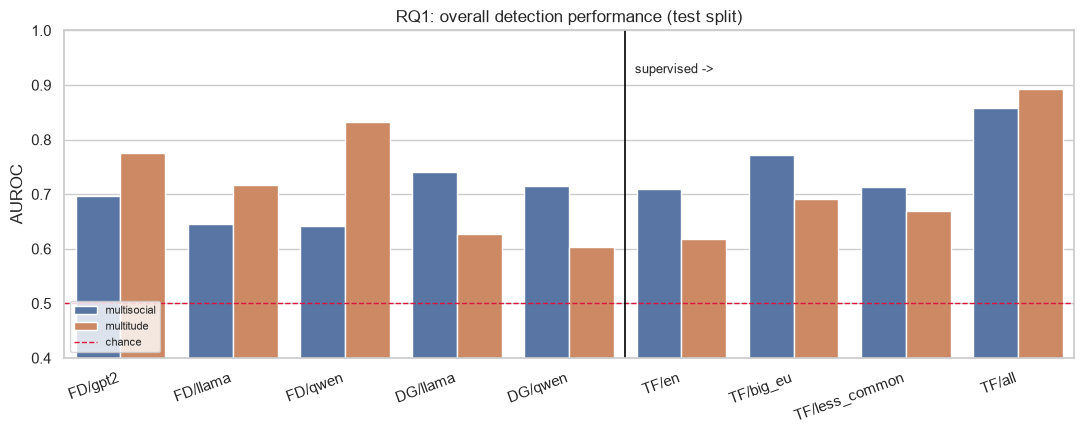

In [6]:
plot_df = tbl.drop(columns="mean").reset_index().melt(id_vars="index", var_name="dataset",
                                                      value_name="auroc").dropna()
plot_df["family"] = np.where(plot_df["index"].str.startswith("TF/"), "supervised TF-IDF",
                             "zero-shot curvature")
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.barplot(plot_df, x="index", y="auroc", hue="dataset", ax=ax)
ax.axhline(0.5, color="crimson", ls="--", lw=1, label="chance")
n_curv = plot_df["index"].nunique() - tfidf.shape[0]
ax.axvline(n_curv - 0.5, color="black", lw=1.2)
ax.text(n_curv - 0.45, 0.94, " supervised ->", fontsize=9, va="top")
ax.set(xlabel="", ylabel="AUROC", ylim=(0.4, 1.0), title="RQ1: overall detection performance (test split)")
ax.legend(loc="lower left", fontsize=8)
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

### 3.1 Does the supervised advantage generalise?

Each TF-IDF config was also scored on the *other* dataset, so we can test transfer directly.
This is the decisive comparison: zero-shot detectors never saw training data at all.

TF-IDF transfer matrix (bold diagonal = in-domain)


eval_on                  multisocial  multitude
trained_on  languages                          
multisocial all               0.8587     0.5953
            big_eu            0.7725     0.5725
            en                0.7093     0.5550
            less_common       0.7136     0.5458
multitude   all               0.5028     0.8927
            big_eu            0.5095     0.6908
            en                0.4965     0.6187
            less_common       0.4881     0.6696

  eval on multisocial  in-domain=0.7635  cross-domain=0.4992  drop=+0.2643
  eval on multitude    in-domain=0.7180  cross-domain=0.5671  drop=+0.1508


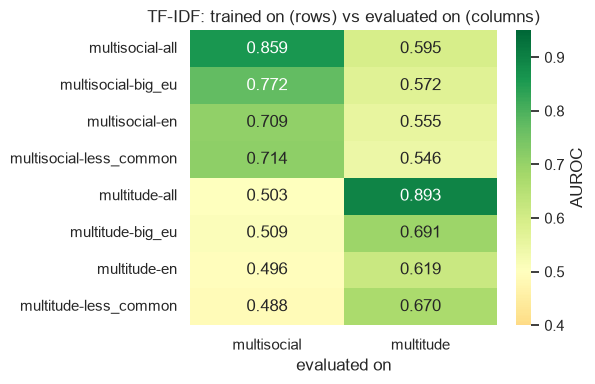

In [7]:
rows = []
for (trained_on, variant, eval_on), g in baseline_all.groupby(["trained_on", "variant", "dataset"]):
    rows.append({"trained_on": trained_on, "languages": variant.split(":")[1], "eval_on": eval_on,
                 "auroc": auroc(g), "in_domain": eval_on == trained_on})
transfer = pd.DataFrame(rows)
piv = transfer.pivot_table(index=["trained_on", "languages"], columns="eval_on", values="auroc")
print("TF-IDF transfer matrix (bold diagonal = in-domain)")
display(piv.round(4))

for ds in transfer["eval_on"].unique():
    s = transfer[transfer["eval_on"] == ds]
    ind, crs = s[s.in_domain]["auroc"].mean(), s[~s.in_domain]["auroc"].mean()
    print(f"  eval on {ds:<12} in-domain={ind:.4f}  cross-domain={crs:.4f}  drop={ind - crs:+.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(piv, annot=True, fmt=".3f", cmap="RdYlGn", center=0.5, vmin=0.4, vmax=0.95,
            cbar_kws={"label": "AUROC"}, ax=ax)
ax.set(title="TF-IDF: trained on (rows) vs evaluated on (columns)", xlabel="evaluated on", ylabel="")
plt.tight_layout(); plt.show()

## 4. RQ2 - languages, resource level, and the model's training data

> *How does the detection efficacy of probability curvature methods vary across high-resource versus
> low-resource languages, and how does it relate to the available languages in the model's training data?*

In [8]:
model_info = pd.DataFrame([
    {"model": "gpt2-xl",     "params": "1.5B", "pretraining": "WebText (English only)",
     "type": "monolingual",            "langs_in_data": 1},
    {"model": "llama3.2-1b", "params": "1.2B", "pretraining": "8 official languages",
     "type": "narrow multilingual",    "langs_in_data": 4},
    {"model": "qwen3-0.6b",  "params": "0.6B", "pretraining": "119 languages claimed",
     "type": "broad multilingual",     "langs_in_data": "all"},
])
display(model_info)
print("`langs_in_data` counts only languages that actually occur in these two datasets.")

,model,params,pretraining,type,langs_in_data
0,gpt2-xl,1.5B,WebText (English only),monolingual,1
1,llama3.2-1b,1.2B,8 official languages,narrow multilingual,4
2,qwen3-0.6b,0.6B,119 languages claimed,broad multilingual,all


`langs_in_data` counts only languages that actually occur in these two datasets.


In [9]:
def per_language(dataset):
    sub = scores[scores["dataset"] == dataset]
    out = {}
    for variant in VARIANT_ORDER:
        g = sub[sub["variant"] == variant]
        if g.empty:
            continue
        out[SHORT[variant]] = {lang: auroc(x) for lang, x in g.groupby("language")}
    t = pd.DataFrame(out)
    t.insert(0, "tier", [RESOURCE_TIER.get(l, "?") for l in t.index])
    return t

lang_tables = {ds: per_language(ds) for ds in sorted(scores["dataset"].unique())}
for ds, t in lang_tables.items():
    sort_col = "FD/qwen" if "FD/qwen" in t.columns else t.columns[1]
    print(f"\n=== {ds.upper()} - per-language AUROC (test split) ===")
    display(t.sort_values(sort_col, ascending=False).round(4))


=== MULTISOCIAL - per-language AUROC (test split) ===


,tier,FD/gpt2,FD/llama,FD/qwen,DG/llama,DG/qwen,TF/en,TF/big_eu,TF/less_common,TF/all
zh,high,0.7029,0.6419,0.7192,0.6385,0.5722,0.6551,0.6579,0.6156,0.6761
de,high,0.7684,0.6163,0.7177,0.7474,0.7165,0.7074,0.8544,0.7088,0.8505
pl,high,0.6812,0.7407,0.6893,0.7916,0.7677,0.6739,0.6816,0.6035,0.8520
el,mid,0.8021,0.7841,0.6840,0.7487,0.7273,0.6461,0.6459,0.6380,0.8650
nl,high,0.7315,0.6846,0.6834,0.7168,0.7045,0.7069,0.8074,0.8782,0.8672
ru,high,0.6804,0.7308,0.6810,0.7254,0.6903,0.6793,0.6467,0.6267,0.8084
ca,mid,0.5377,0.6093,0.6689,0.6303,0.6324,0.7084,0.8434,0.7561,0.8905
es,high,0.7526,0.6218,0.6662,0.7720,0.7264,0.7105,0.8847,0.7399,0.8797
ar,high,0.7534,0.6781,0.6654,0.6232,0.6016,0.7448,0.7523,0.7491,0.8457
pt,high,0.7316,0.5967,0.6557,0.8041,0.7626,0.6829,0.8855,0.6482,0.8683



=== MULTITUDE - per-language AUROC (test split) ===


,tier,FD/gpt2,FD/llama,FD/qwen,DG/llama,DG/qwen,TF/en,TF/big_eu,TF/less_common,TF/all
en,high,0.9517,0.9611,0.9730,0.7448,0.7235,0.9576,0.9489,0.6969,0.9292
ro,mid,0.7643,0.9736,0.9580,0.7230,0.6540,0.6424,0.6474,0.6007,0.9363
pt,high,0.8862,0.9418,0.9462,0.6813,0.6347,0.6632,0.9271,0.7232,0.9084
ca,mid,0.8267,0.9366,0.9335,0.7001,0.6882,0.6168,0.8099,0.6220,0.9212
es,high,0.9060,0.9540,0.9285,0.7210,0.6563,0.6197,0.9130,0.5304,0.8878
de,high,0.9039,0.9329,0.9231,0.6169,0.5909,0.5526,0.9289,0.5410,0.8973
nl,high,0.9221,0.9339,0.9153,0.6516,0.6572,0.6328,0.6486,0.9709,0.9337
cs,high,0.8203,0.7288,0.8922,0.6623,0.6095,0.5102,0.6059,0.6400,0.9203
hr,mid,0.8030,0.9061,0.8918,0.7111,0.6469,0.6037,0.6366,0.5696,0.9055
pl,high,0.7995,0.8842,0.8879,0.6586,0.6423,0.6022,0.6547,0.6697,0.8571


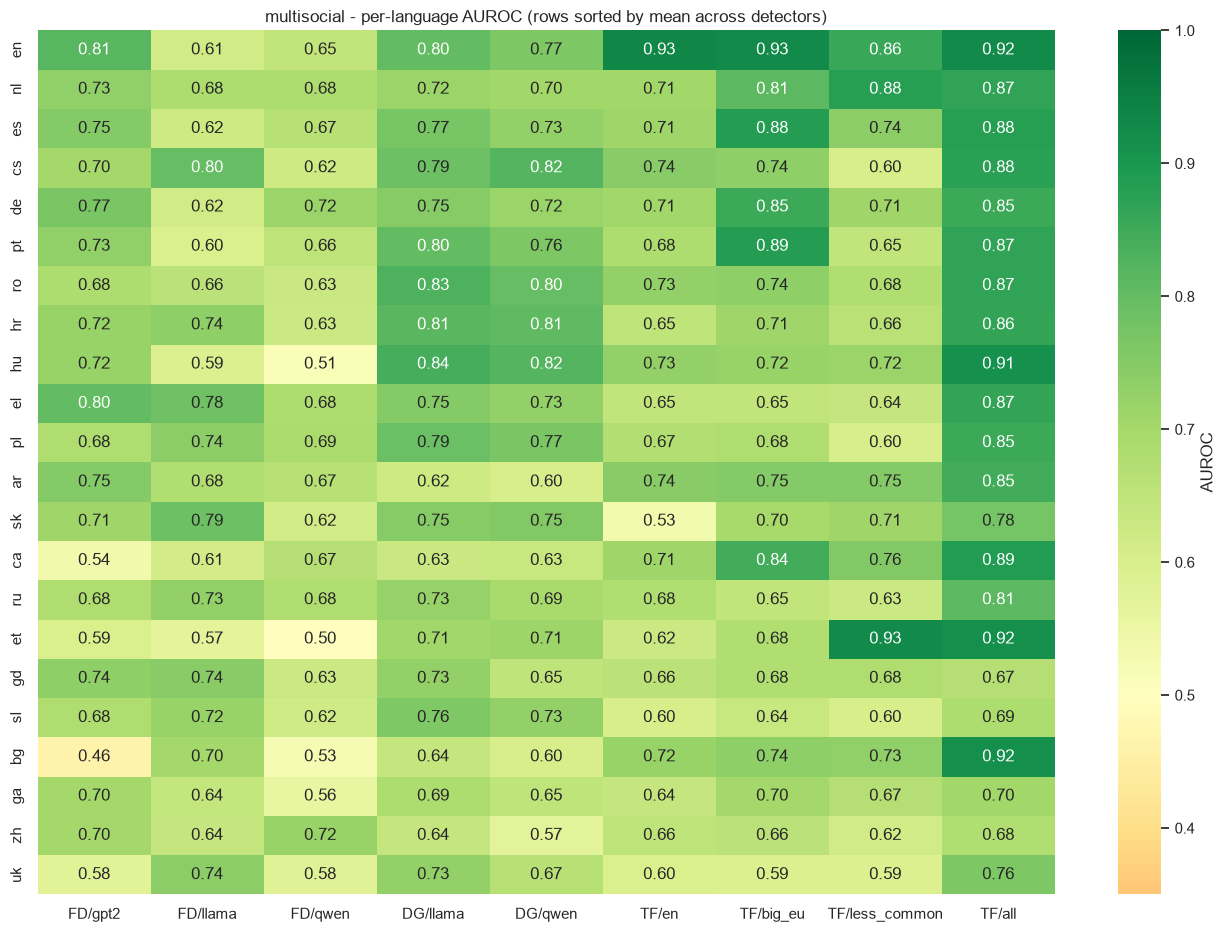

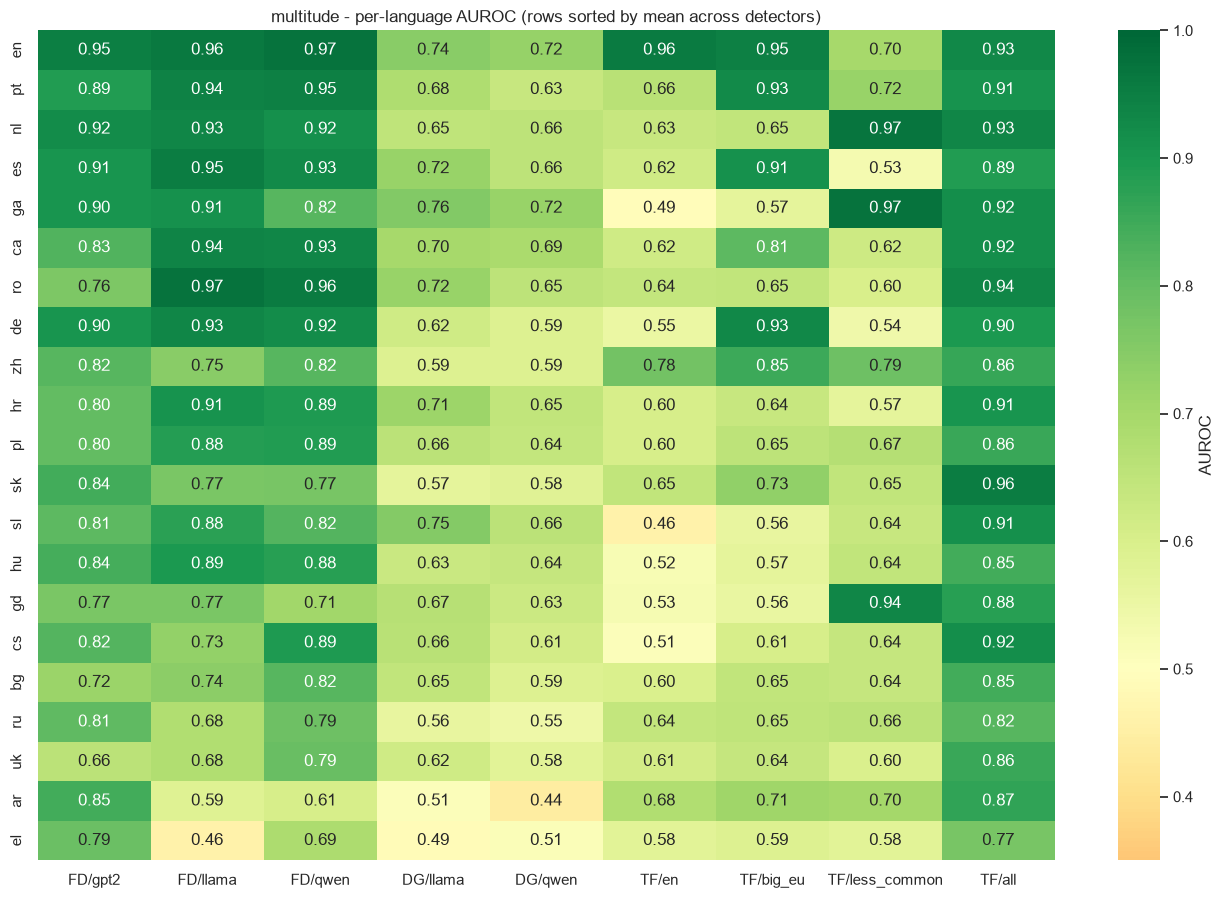

In [10]:
for ds, t in lang_tables.items():
    num = t.drop(columns="tier")
    order = num.mean(axis=1).sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(1.15 * len(num.columns) + 3, 0.34 * len(num) + 2))
    sns.heatmap(num.loc[order], annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
                vmin=0.35, vmax=1.0, cbar_kws={"label": "AUROC"}, ax=ax)
    ax.set(title=f"{ds} - per-language AUROC (rows sorted by mean across detectors)", xlabel="", ylabel="")
    plt.tight_layout(); plt.show()

### 4.1 Is the language in the scoring model's pretraining data?

In [11]:
rows = []
for ds, t in lang_tables.items():
    for variant in VARIANT_ORDER:
        if not variant.startswith(("fastdetect", "detectgpt")):
            continue
        model = variant.split(":")[1]
        covered = MODEL_COVERAGE.get(model)
        col = SHORT[variant]
        if covered is None or col not in t.columns:
            continue   # qwen3 covers everything -> no contrast to measure
        seen = t.loc[[l in covered for l in t.index], col].dropna()
        unseen = t.loc[[l not in covered for l in t.index], col].dropna()
        if len(seen) and len(unseen):
            rows.append({"dataset": ds, "detector": col, "model": model,
                         "n_seen": len(seen), "seen_auroc": seen.mean(),
                         "n_unseen": len(unseen), "unseen_auroc": unseen.mean(),
                         "delta": seen.mean() - unseen.mean()})
coverage = pd.DataFrame(rows)
print("Languages IN the scoring model's documented pretraining vs NOT")
display(coverage.round(4))
print(f"mean delta across all {len(coverage)} comparisons: {coverage['delta'].mean():+.4f}")

Languages IN the scoring model's documented pretraining vs NOT


,dataset,detector,model,n_seen,seen_auroc,n_unseen,unseen_auroc,delta
0,multisocial,FD/gpt2,gpt2-xl,1,0.8149,21,0.6873,0.1275
1,multisocial,FD/llama,llama3.2-1b,4,0.6124,18,0.6976,-0.0852
2,multisocial,DG/llama,llama3.2-1b,4,0.7812,18,0.7301,0.0511
3,multitude,FD/gpt2,gpt2-xl,1,0.9517,20,0.8214,0.1303
4,multitude,FD/llama,llama3.2-1b,4,0.9475,17,0.7919,0.1556
5,multitude,DG/llama,llama3.2-1b,4,0.6910,17,0.6409,0.0501


mean delta across all 6 comparisons: +0.0716


### 4.2 High- vs low-resource tiers

,dataset,detector,high,mid,low,high_minus_low
0,multisocial,FD/gpt2,0.7317,0.6495,0.7180,0.0137
1,multisocial,FD/llama,0.6724,0.6897,0.6924,-0.0199
2,multisocial,FD/qwen,0.6749,0.5970,0.5911,0.0838
3,multisocial,DG/llama,0.7408,0.7445,0.7066,0.0343
4,multisocial,DG/qwen,0.7131,0.7249,0.6510,0.0621
5,multisocial,TF/en,0.7237,0.6541,0.6497,0.0740
6,multisocial,TF/big_eu,0.7836,0.6994,0.6897,0.0939
7,multisocial,TF/less_common,0.7032,0.7016,0.6749,0.0282
8,multisocial,TF/all,0.8447,0.8458,0.6868,0.1579
9,multitude,FD/gpt2,0.8660,0.7833,0.8354,0.0305


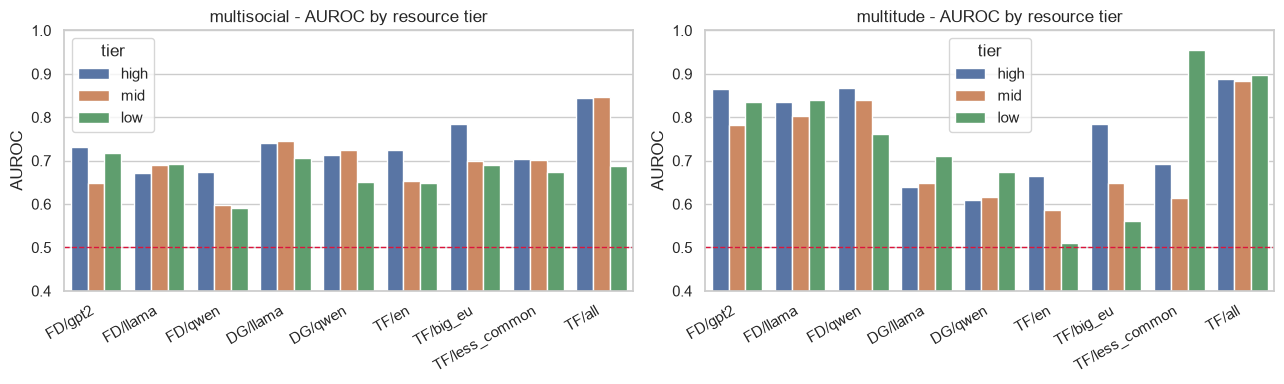

Tiers are a coarse approximation set in the config cell - edit RESOURCE_TIER to taste.


In [ ]:
tier_rows = []
for ds, t in lang_tables.items():
    for col in t.columns.drop("tier"):
        means = t.groupby("tier")[col].mean()
        tier_rows.append({"dataset": ds, "detector": col,
                          "high": means.get("high"), "mid": means.get("mid"),
                          "low": means.get("low"),
                          "high_minus_low": means.get("high", np.nan) - means.get("low", np.nan)})
tiers = pd.DataFrame(tier_rows)
display(tiers.round(4))

fig, axes = plt.subplots(1, len(lang_tables), figsize=(6.5 * len(lang_tables), 4), squeeze=False)
for ax, (ds, t) in zip(axes[0], lang_tables.items()):
    long = (t.melt(id_vars="tier", var_name="detector", value_name="auroc").dropna())
    sns.barplot(long, x="detector", y="auroc", hue="tier",
                hue_order=["high", "mid", "low"], ax=ax, errorbar=None)
    ax.axhline(0.5, color="crimson", ls="--", lw=1)
    ax.set(title=f"{ds} - AUROC by resource tier", xlabel="", ylabel="AUROC", ylim=(0.4, 1.0))
    ax.tick_params(axis="x", rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
plt.tight_layout(); plt.show()

In [13]:
rows = []
for ds, t in lang_tables.items():
    for col in t.columns.drop("tier"):
        v = t[col].dropna()
        rows.append({"dataset": ds, "detector": col, "mean": v.mean(), "sd": v.std(),
                     "min": v.min(), "worst_language": v.idxmin(), "max": v.max(),
                     "below_chance": int((v < 0.5).sum())})
uniformity = pd.DataFrame(rows)
display(uniformity.round(4))

,dataset,detector,mean,sd,min,worst_language,max,below_chance
0,multisocial,FD/gpt2,0.6931,0.0837,0.4644,bg,0.8149,1
1,multisocial,FD/llama,0.6821,0.0700,0.5672,et,0.7985,0
2,multisocial,FD/qwen,0.6319,0.0624,0.4988,et,0.7192,1
3,multisocial,DG/llama,0.7394,0.0653,0.6232,ar,0.8415,0
4,multisocial,DG/qwen,0.7128,0.0728,0.5722,zh,0.8238,0
5,multisocial,TF/en,0.6853,0.0766,0.5331,sk,0.9329,0
6,multisocial,TF/big_eu,0.7368,0.0920,0.5932,uk,0.9276,0
7,multisocial,TF/less_common,0.6999,0.0925,0.5920,uk,0.9286,0
8,multisocial,TF/all,0.8309,0.0815,0.6692,gd,0.9241,0
9,multitude,FD/gpt2,0.8276,0.0702,0.6582,uk,0.9517,0


## 5. Per-generator performance

Each generator is scored against **all** human rows of that dataset, so the numbers are comparable
across generators.

In [14]:
def per_generator(dataset):
    sub = scores[scores["dataset"] == dataset]
    out = {}
    for variant in VARIANT_ORDER:
        g = sub[sub["variant"] == variant]
        if g.empty:
            continue
        human = g[g["label"] == 0]
        out[SHORT[variant]] = {gen: auroc(pd.concat([human, x]))
                               for gen, x in g[g["label"] == 1].groupby("multi_label")}
    return pd.DataFrame(out)

gen_tables = {ds: per_generator(ds) for ds in sorted(scores["dataset"].unique())}
for ds, t in gen_tables.items():
    print(f"\n=== {ds.upper()} - per-generator AUROC (test split) ===")
    display(t.round(4))
    print(f"  spread (max-min) per detector:\n{(t.max() - t.min()).round(4).to_string()}")


=== MULTISOCIAL - per-generator AUROC (test split) ===


,FD/gpt2,FD/llama,FD/qwen,DG/llama,DG/qwen,TF/en,TF/big_eu,TF/less_common,TF/all
Mistral-7B-Instruct-v0.2,0.6442,0.5436,0.5315,0.7132,0.7080,0.7243,0.7835,0.7339,0.8627
aya-101,0.6924,0.6516,0.6962,0.6938,0.6391,0.6655,0.7290,0.6709,0.7918
gemini,0.6741,0.6788,0.5275,0.8596,0.8779,0.7452,0.8033,0.7695,0.9178
gpt-3.5-turbo-0125,0.6271,0.6104,0.6364,0.7173,0.6933,0.6965,0.7573,0.6942,0.8459
opt-iml-max-30b,0.7470,0.6061,0.6435,0.6192,0.5652,0.6658,0.7234,0.6648,0.7880
v5-Eagle-7B-HF,0.7560,0.7206,0.7436,0.8089,0.7852,0.7409,0.8122,0.7414,0.9131
vicuna-13b,0.7411,0.7072,0.7098,0.7662,0.7281,0.7217,0.7930,0.7159,0.8842


  spread (max-min) per detector:
FD/gpt2           0.1288
FD/llama          0.1770
FD/qwen           0.2162
DG/llama          0.2404
DG/qwen           0.3126
TF/en             0.0797
TF/big_eu         0.0888
TF/less_common    0.1046
TF/all            0.1297

=== MULTITUDE - per-generator AUROC (test split) ===


,FD/gpt2,FD/llama,FD/qwen,DG/llama,DG/qwen,TF/en,TF/big_eu,TF/less_common,TF/all
Llama-2-70b-chat-hf,0.8163,0.7987,0.9260,0.7644,0.6944,0.6544,0.7412,0.6909,0.9552
Mistral-7B-Instruct-v0.2,0.6910,0.6842,0.6928,0.6139,0.6095,0.5909,0.6686,0.6709,0.9124
aya-101,0.7505,0.7607,0.8355,0.6657,0.6612,0.5451,0.5906,0.6061,0.8058
gpt-3.5-turbo-0125,0.7309,0.7350,0.8575,0.6966,0.6138,0.6374,0.7162,0.6556,0.9340
opt-iml-max-30b,0.8513,0.5651,0.8139,0.3443,0.3860,0.6391,0.6805,0.6969,0.8125
v5-Eagle-7B-HF,0.7731,0.7399,0.8364,0.6726,0.6547,0.6281,0.7036,0.6674,0.8880
vicuna-13b,0.8147,0.7298,0.8681,0.6328,0.6031,0.6371,0.7363,0.7005,0.9419


  spread (max-min) per detector:
FD/gpt2           0.1603
FD/llama          0.2335
FD/qwen           0.2332
DG/llama          0.4201
DG/qwen           0.3084
TF/en             0.1093
TF/big_eu         0.1506
TF/less_common    0.0944
TF/all            0.1494


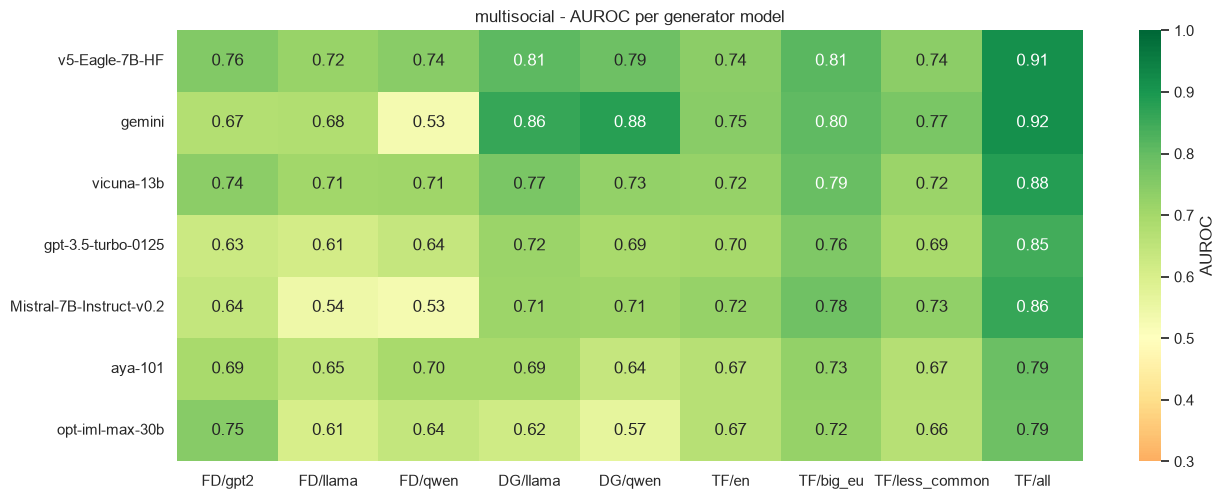

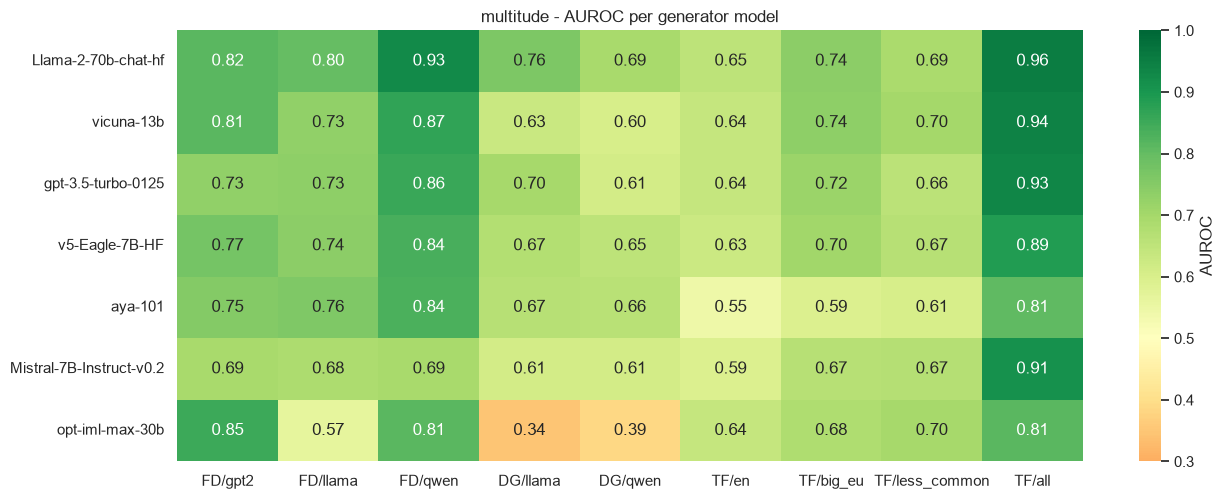

Below-chance (INVERTED) detector/generator pairs - the detector is reliably wrong here:


,dataset,detector,generator,auroc
0,multitude,DG/llama,opt-iml-max-30b,0.3443
1,multitude,DG/qwen,opt-iml-max-30b,0.3860


In [15]:
for ds, t in gen_tables.items():
    order = t.mean(axis=1).sort_values(ascending=False).index
    fig, ax = plt.subplots(figsize=(1.15 * len(t.columns) + 3, 0.45 * len(t) + 2))
    sns.heatmap(t.loc[order], annot=True, fmt=".2f", cmap="RdYlGn", center=0.5,
                vmin=0.3, vmax=1.0, cbar_kws={"label": "AUROC"}, ax=ax)
    ax.set(title=f"{ds} - AUROC per generator model", xlabel="", ylabel="")
    plt.tight_layout(); plt.show()

inverted = []
for ds, t in gen_tables.items():
    for col in t.columns:
        for gen, v in t[col].items():
            if pd.notna(v) and v < 0.5:
                inverted.append({"dataset": ds, "detector": col, "generator": gen, "auroc": v})
if inverted:
    print("Below-chance (INVERTED) detector/generator pairs - the detector is reliably wrong here:")
    display(pd.DataFrame(inverted).sort_values("auroc").round(4).reset_index(drop=True))

## 6. Export

Everything above as one tidy CSV, plus the wide tables.

In [16]:
tidy = []
for (ds, variant), g in scores.groupby(["dataset", "variant"]):
    tidy.append({"dataset": ds, "variant": variant, "scope": "OVERALL", "key": "ALL",
                 "n": len(g), "auroc": auroc(g)})
    for lang, x in g.groupby("language"):
        tidy.append({"dataset": ds, "variant": variant, "scope": "language", "key": lang,
                     "n": len(x), "auroc": auroc(x)})
    human = g[g["label"] == 0]
    for gen, x in g[g["label"] == 1].groupby("multi_label"):
        tidy.append({"dataset": ds, "variant": variant, "scope": "generator", "key": gen,
                     "n": len(x), "auroc": auroc(pd.concat([human, x]))})
tidy = pd.DataFrame(tidy).round(4)
tidy.to_csv(OUT_DIR / "all_results_tidy.csv", index=False)

for ds, t in lang_tables.items():
    t.round(4).to_csv(OUT_DIR / f"per_language_{ds}.csv")
for ds, t in gen_tables.items():
    t.round(4).to_csv(OUT_DIR / f"per_generator_{ds}.csv")
transfer.round(4).to_csv(OUT_DIR / "tfidf_transfer.csv", index=False)
coverage.round(4).to_csv(OUT_DIR / "pretraining_coverage.csv", index=False)
uniformity.round(4).to_csv(OUT_DIR / "uniformity.csv", index=False)

print(f"wrote {len(list(OUT_DIR.glob('*.csv')))} CSVs to {OUT_DIR}/")
for f in sorted(OUT_DIR.glob("*.csv")):
    print("  ", f.name)

wrote 8 CSVs to /Users/julian/Documents/MNLP/Multi-lingual-NLP/analysis/output/
   all_results_tidy.csv
   per_generator_multisocial.csv
   per_generator_multitude.csv
   per_language_multisocial.csv
   per_language_multitude.csv
   pretraining_coverage.csv
   tfidf_transfer.csv
   uniformity.csv
